In [1]:
import gc
import torch

torch.cuda.empty_cache()
gc.collect()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from time import time

tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-2-7b-hf')
model = AutoModelForCausalLM.from_pretrained('meta-llama/Llama-2-7b-hf', device_map="auto")
model.hf_device_map

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

{'model.embed_tokens': 0,
 'model.layers.0': 0,
 'model.layers.1': 0,
 'model.layers.2': 0,
 'model.layers.3': 0,
 'model.layers.4': 0,
 'model.layers.5': 0,
 'model.layers.6': 0,
 'model.layers.7': 0,
 'model.layers.8': 0,
 'model.layers.9': 0,
 'model.layers.10': 0,
 'model.layers.11': 0,
 'model.layers.12': 0,
 'model.layers.13': 0,
 'model.layers.14': 0,
 'model.layers.15': 0,
 'model.layers.16': 1,
 'model.layers.17': 1,
 'model.layers.18': 1,
 'model.layers.19': 1,
 'model.layers.20': 1,
 'model.layers.21': 1,
 'model.layers.22': 1,
 'model.layers.23': 1,
 'model.layers.24': 1,
 'model.layers.25': 1,
 'model.layers.26': 1,
 'model.layers.27': 1,
 'model.layers.28': 1,
 'model.layers.29': 1,
 'model.layers.30': 1,
 'model.layers.31': 1,
 'model.norm': 1,
 'model.rotary_emb': 1,
 'lm_head': 1}

In [3]:
q_proj_weight_7 = model.model.layers[7].self_attn.q_proj.weight
q_proj_weight_15 = model.model.layers[15].self_attn.q_proj.weight
q_proj_weight_23 = model.model.layers[23].self_attn.q_proj.weight

k_proj_weight_7 = model.model.layers[7].self_attn.k_proj.weight
k_proj_weight_15 = model.model.layers[15].self_attn.k_proj.weight
k_proj_weight_23 = model.model.layers[23].self_attn.k_proj.weight

v_proj_weight_7 = model.model.layers[7].self_attn.v_proj.weight
v_proj_weight_15 = model.model.layers[15].self_attn.v_proj.weight
v_proj_weight_23 = model.model.layers[23].self_attn.v_proj.weight

o_proj_weight_7 = model.model.layers[7].self_attn.o_proj.weight
o_proj_weight_15 = model.model.layers[15].self_attn.o_proj.weight
o_proj_weight_23 = model.model.layers[23].self_attn.o_proj.weight

mlp_gate_weight_7 = model.model.layers[7].mlp.gate_proj.weight
mlp_gate_weight_15 = model.model.layers[15].mlp.gate_proj.weight
mlp_gate_weight_23 = model.model.layers[23].mlp.gate_proj.weight

mlp_up_weight_7 = model.model.layers[7].mlp.up_proj.weight
mlp_up_weight_15 = model.model.layers[15].mlp.up_proj.weight
mlp_up_weight_23 = model.model.layers[23].mlp.up_proj.weight

mlp_down_weight_7 = model.model.layers[7].mlp.down_proj.weight
mlp_down_weight_15 = model.model.layers[15].mlp.down_proj.weight
mlp_down_weight_23 = model.model.layers[23].mlp.down_proj.weight

In [4]:
# import numpy as np
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D

# # ---- Generate example data (replace with your own) ----
# np.random.seed(69)
# n = 30
# x1 = np.random.uniform(50, 200, n)
# x2 = np.random.uniform(2000, 4500, n)

# # underlying plane + noise
# y = - 8*x1 - 0.6*x2 + np.random.normal(0, 200, n)

# # ---- Fit plane (linear regression) ----
# X = np.column_stack((np.ones(n), x1, x2))
# beta = np.linalg.lstsq(X, y, rcond=None)[0]
# y_pred = beta[0] + beta[1]*x1 + beta[2]*x2

# # ---- Create grid for surface ----
# x1_grid = np.linspace(x1.min(), x1.max(), 40)
# x2_grid = np.linspace(x2.min(), x2.max(), 40)
# X1, X2 = np.meshgrid(x1_grid, x2_grid)
# Y = beta[0] + beta[1]*X1 + beta[2]*X2

# # ---- Plot ----
# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection='3d')

# # Scatter points
# ax.scatter(x1, x2, y,
#            color='#1f77b4',
#            s=50,
#            alpha=0.9,
#            edgecolor='k',
#            linewidth=0.5)


# # Plane normal
# normal = np.array([beta[1], beta[2], -1.0])
# normal = normal / np.linalg.norm(normal)

# # Create two orthonormal vectors spanning the plane
# # (basis vectors for the plane)
# v1 = np.cross(normal, [0, 0, 1])
# if np.linalg.norm(v1) < 1e-6:
#     v1 = np.cross(normal, [0, 1, 0])
# v1 = v1 / np.linalg.norm(v1)

# v2 = np.cross(normal, v1)

# # Circle size
# r = 1  # adjust based on your scale

# theta = np.linspace(0, 2*np.pi, 50)

# # Draw circles lying on the plane
# for xi, xj, yhat in zip(x1, x2, y_pred):
#     circle = (
#         np.array([xi, xj, yhat]).reshape(3,1)
#         + r * (np.outer(v1, np.cos(theta)) + np.outer(v2, np.sin(theta)))
#     )
    
#     ax.plot(circle[0], circle[1], circle[2],
#             color='red',
#             linewidth=1.5)


# # Dashed residual lines (point -> plane)
# for xi, xj, yi, yhat in zip(x1, x2, y, y_pred):
#     ax.plot([xi, xi], [xj, xj], [yi, yhat],
#             color='black',
#             linestyle='--',
#             linewidth=0.8,
#             alpha=1)

# # Surface
# surf = ax.plot_surface(X1, X2, Y,
#                        cmap='viridis',
#                        alpha=0.5,
#                        edgecolor='none',
#                        antialiased=True)

# # ---- Labels & styling ----
# ax.set_xlabel('$x_1$', labelpad=10)
# ax.set_ylabel('$x_2$', labelpad=10)
# ax.set_zlabel('y', labelpad=10)

# # Improve viewing angle
# ax.view_init(elev=10, azim=-70)

# # Light grid aesthetic
# ax.xaxis.pane.set_alpha(0.1)
# ax.yaxis.pane.set_alpha(0.1)
# ax.zaxis.pane.set_alpha(0.1)

# # ---- Save at 300 DPI ----
# plt.tight_layout()
# plt.savefig('pretty_3d_regression.png', dpi=300)
# plt.show()

In [5]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib import cm

# import matplotlib as mpl
# mpl.rcParams['figure.dpi'] = 300

# # 1. Define the new surface function
# def f(x, y):
#     return (x**2 + y**2)/10 + np.cos(x)*np.sin(y)

# # 2. Define the partial derivatives (gradients)
# def df_dx(x, y):
#     return x/5 - np.sin(x)*np.sin(y)

# def df_dy(x, y):
#     return y/5 + np.cos(x)*np.cos(y)

# # 3. Create a meshgrid for plotting the 3D surface
# x = np.linspace(-5, 5, 100)
# y = np.linspace(-5, 5, 100)
# X, Y = np.meshgrid(x, y)
# Z = f(X, Y)

# # 4. Simulate Gradient Descent with an accelerating step size
# x_pos, y_pos = -4.5, 4.5  # Starting coordinates
# path_x, path_y, path_z = [x_pos], [y_pos], [f(x_pos, y_pos)]

# base_lr = 0.15 # Base learning rate
# for i in range(25):
#     # Dynamically increase the learning rate to space dots farther apart downwards
#     # current_lr = base_lr * (1 + 0.20 * i) 
#     current_lr = base_lr
    
#     grad_x = df_dx(x_pos, y_pos)
#     grad_y = df_dy(x_pos, y_pos)
    
#     x_pos = x_pos - current_lr * grad_x
#     y_pos = y_pos - current_lr * grad_y
    
#     path_x.append(x_pos)
#     path_y.append(y_pos)
#     path_z.append(f(x_pos, y_pos))

# # 5. Render the Visualization
# fig = plt.figure(figsize=(9, 6))
# ax = fig.add_subplot(111, projection='3d')

# # Reduce surface alpha slightly (e.g., to 0.7) to help the path stand out
# surf = ax.plot_surface(X, Y, Z, cmap=cm.viridis, alpha=0.7, edgecolor='k', linewidth=0.2)

# # --- THE FIX ---
# # 1. Add a small vertical offset so the points don't clip through the surface
# z_offset = 0.3 
# path_z_elevated = [z + z_offset for z in path_z]

# # 2. Add zorder=10 to force it to draw on top, and make it a bright contrasting color
# ax.plot(path_x, path_y, path_z_elevated, color='black', marker='o', markersize=3, 
#         linestyle='dashed', linewidth=.5, zorder=10)
# # ---------------

# # 3. Add a specific, separate red dot for the starting point
# ax.scatter(path_x[0], path_y[0], path_z_elevated[0], color='red', s=35, edgecolors='black', linewidth=0.5, zorder=10, alpha=1.0)

# # Add the 2D contour projection at the base
# offset_val = np.min(Z) - 2
# ax.contour(X, Y, Z, zdir='z', offset=offset_val, levels=30, linewidths=.7, cmap=cm.viridis, alpha=0.5)

# # Formatting
# ax.set_zlim(offset_val, np.max(Z))
# ax.set_axis_off()

# ax.view_init(azim=305)

# plt.tight_layout()
# plt.show()

In [6]:
from test_dbsf import *

In [7]:
# diagram0a = test_double_sparse(matrix=mlp_up_weight_7, mask_type='2to4', total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

In [8]:
# diagram0b = test_double_sparse(matrix=q_proj_weight_7, mask_type='2to4', total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

In [9]:


q7_4x4 = test_double_sparse(q_proj_weight_7, 0.5, 0.5, 1, mask_type='blocks_alt')
q15_4x4 = test_double_sparse(q_proj_weight_15, 0.5, 0.5, 1, mask_type='blocks_alt')
q23_4x4 = test_double_sparse(q_proj_weight_23, 0.5, 0.5, 1, mask_type='blocks_alt')

# k6 = test_double_block_sparse(k_proj_weight_7, 0.5, 0.5, 1)
# k16 = test_double_block_sparse(k_proj_weight_15, 0.5, 0.5, 1)
# k28 = test_double_block_sparse(k_proj_weight_23, 0.5, 0.5, 1)

# v6 = test_double_block_sparse(v_proj_weight_7, 0.5, 0.5, 1)
# v16 = test_double_block_sparse(v_proj_weight_15, 0.5, 0.5, 1)
# v28 = test_double_block_sparse(v_proj_weight_23, 0.5, 0.5, 1)

o7_4x4 = test_double_sparse(o_proj_weight_7, 0.5, 0.5, 1, mask_type='blocks_alt')
o15_4x4 = test_double_sparse(o_proj_weight_15, 0.5, 0.5, 1, mask_type='blocks_alt')
o23_4x4 = test_double_sparse(o_proj_weight_23, 0.5, 0.5, 1, mask_type='blocks_alt')

# mg6 = test_double_block_sparse(mlp_gate_weight_7, 0.5, 0.5, 1)
# mg16 = test_double_block_sparse(mlp_gate_weight_15, 0.5, 0.5, 1)
# mg28 = test_double_block_sparse(mlp_gate_weight_23, 0.5, 0.5, 1)


mu7_4x4 = test_double_sparse(mlp_up_weight_7, 0.5, 0.5, 1, mask_type='blocks_alt')
mu15_4x4 = test_double_sparse(mlp_up_weight_15, 0.5, 0.5, 1, mask_type='blocks_alt')
mu23_4x4 = test_double_sparse(mlp_up_weight_23, 0.5, 0.5, 1, mask_type='blocks_alt')


# md6 = test_double_block_sparse(mlp_down_weight_7, 0.5, 0.5, 1)
# md16 = test_double_block_sparse(mlp_down_weight_15, 0.5, 0.5, 1)
# md28 = test_double_block_sparse(mlp_down_weight_23, 0.5, 0.5, 1)

res2 = {
    "q7": q7_4x4,
    "q15": q15_4x4,
    "q23": q23_4x4,
    "o7": o7_4x4,
    "o15": o15_4x4,
    "o23": o23_4x4,
    "mu7": mu7_4x4,
    "mu15": mu15_4x4,
    "mu23": mu23_4x4,
}

print(res2)

Frobenius pre-finalization:  17.123369216918945
Frobenius norm: 17.123369216918945
A: tensor([[ 1.6564,  0.6361,  0.0000,  0.6980],
        [ 0.2186,  1.8148,  0.0000, -0.5257],
        [-0.0000, -0.0000,  1.3541, -0.1608],
        [ 0.0000, -0.0000,  0.1391,  2.0442]])
B: tensor([[-0.0000, -0.0000, -0.0000,  0.0000],
        [-0.0000,  0.0000,  0.0012,  0.0005],
        [-0.0000,  0.0000,  0.0000,  0.0000],
        [-0.0000,  0.0000,  0.0020, -0.0018]])
A.size() = torch.Size([4096, 4096])
B.size() = torch.Size([4096, 4096])
AB: tensor([[ 5.3792e-03, -7.0524e-04,  8.7413e-03,  ...,  5.9972e-03,
         -1.6036e-02,  3.6362e-03],
        [ 1.0150e-03,  7.2697e-03, -9.9019e-05,  ...,  1.6294e-02,
         -8.4950e-03, -1.8161e-02],
        [ 7.7938e-04,  5.9086e-03, -1.4172e-02,  ..., -1.6928e-02,
         -4.0646e-03,  8.2314e-03],
        ...,
        [ 3.8060e-03, -3.9747e-02, -3.0555e-02,  ..., -1.3920e-02,
          3.6219e-02,  3.0909e-02],
        [ 1.0812e-02,  4.8766e-02, -4.42

In [10]:
wertzuiop$dk

rho0_1 = {'q6': 38.28483200073242, 'q16': 41.81094741821289, 'q28': 42.95512771606445, 'k6': 38.908687591552734, 'k16': 41.508201599121094, 'k28': 44.1080207824707, 'v6': 29.54777717590332, 'v16': 36.39766311645508, 'v28': 45.71820068359375, 'o6': 29.311275482177734, 'o16': 36.19401168823242, 'o28': 45.460025787353516, 'mg6': 77.41944122314453, 'mg16': 73.94796752929688, 'mg28': 79.48108673095703, 'mu6': 71.15171813964844, 'mu16': 75.19181823730469, 'mu28': 77.77134704589844, 'md6': 69.53863525390625, 'md16': 74.77937316894531, 'md28': 76.87718200683594}
rho0_25 = {'q6': 23.51824378967285, 'q16': 24.419002532958984, 'q28': 25.05255889892578, 'k6': 24.227033615112305, 'k16': 24.571317672729492, 'k28': 25.73602294921875, 'v6': 16.758159637451172, 'v16': 20.84759521484375, 'v28': 26.980669021606445, 'o6': 16.53089714050293, 'o16': 20.8168888092041, 'o28': 26.76836395263672, 'mg6': 51.05893325805664, 'mg16': 48.74462127685547, 'mg28': 53.66313171386719, 'mu6': 47.938385009765625, 'mu16': 49.990718841552734, 'mu28': 52.56291961669922, 'md6': 45.41615676879883, 'md16': 50.24744415283203, 'md28': 51.592613220214844}
rho0_4 = {'q6': 22.469511032104492, 'q16': 23.110801696777344, 'q28': 23.52638816833496, 'k6': 23.099891662597656, 'k16': 23.26699447631836, 'k28': 24.107126235961914, 'v6': 15.425777435302734, 'v16': 18.988574981689453, 'v28': 24.501873016357422, 'o6': 15.216079711914062, 'o16': 18.938823699951172, 'o28': 24.330175399780273, 'mg6': 45.06290817260742, 'mg16': 43.14164352416992, 'mg28': 47.04617691040039, 'mu6': 41.64407730102539, 'mu16': 43.6635627746582, 'mu28': 45.6197509765625, 'md6': 39.907691955566406, 'md16': 43.687992095947266, 'md28': 44.9075927734375}
rho0_45 = {'q6': 22.449012756347656, 'q16': 23.10077476501465, 'q28': 23.53615951538086, 'k6': 23.07236671447754, 'k16': 23.25179100036621, 'k28': 24.100126266479492, 'v6': 15.434228897094727, 'v16': 19.02528953552246, 'v28': 24.551864624023438, 'o6': 15.225590705871582, 'o16': 18.96786880493164, 'o28': 24.350099563598633, 'mg6': 44.62250900268555, 'mg16': 42.735294342041016, 'mg28': 46.51319885253906, 'mu6': 41.16019058227539, 'mu16': 43.20261764526367, 'mu28': 45.076969146728516, 'md6': 39.54338073730469, 'md16': 43.18386459350586, 'md28': 44.39499282836914}
rho0_5 = {'q6': 22.455705642700195, 'q16': 23.122785568237305, 'q28': 23.5751953125, 'k6': 23.070526123046875, 'k16': 23.269611358642578, 'k28': 24.14223289489746, 'v6': 15.469905853271484, 'v16': 19.081266403198242, 'v28': 24.62716293334961, 'o6': 15.259190559387207, 'o16': 19.02943992614746, 'o28': 24.440811157226562, 'mg6': 44.5167350769043, 'mg16': 42.6567497253418, 'mg28': 46.30974197387695, 'mu6': 40.978485107421875, 'mu16': 43.06048583984375, 'mu28': 44.88608169555664, 'md6': 39.479549407958984, 'md16': 43.00800323486328, 'md28': 44.223609924316406}
rho0_55 = {'q6': 22.486738204956055, 'q16': 23.170974731445312, 'q28': 23.63525390625, 'k6': 23.09551239013672, 'k16': 23.314729690551758, 'k28': 24.204139709472656, 'v6': 15.521681785583496, 'v16': 19.14906883239746, 'v28': 24.70897102355957, 'o6': 15.307882308959961, 'o16': 19.096717834472656, 'o28': 24.51502799987793, 'mg6': 44.59880828857422, 'mg16': 42.730621337890625, 'mg28': 46.34324264526367, 'mu6': 41.042598724365234, 'mu16': 43.14803695678711, 'mu28': 44.941871643066406, 'md6': 39.59388732910156, 'md16': 43.07436752319336, 'md28': 44.291587829589844}
rho0_75 = {'q6': 22.829673767089844, 'q16': 23.569107055664062, 'q28': 24.027490615844727, 'k6': 23.43270492553711, 'k16': 23.684635162353516, 'k28': 24.588211059570312, 'v6': 15.80319881439209, 'v16': 19.48728370666504, 'v28': 25.122241973876953, 'o6': 15.588659286499023, 'o16': 19.435802459716797, 'o28': 24.927749633789062, 'mg6': 44.952911376953125, 'mg16': 43.08030700683594, 'mg28': 46.670372009277344, 'mu6': 41.38418960571289, 'mu16': 43.51534652709961, 'mu28': 45.30218505859375, 'md6': 39.96250534057617, 'md16': 43.427677154541016, 'md28': 44.66238784790039}
rho1 = {'q6': 23.50457191467285, 'q16': 24.298742294311523, 'q28': 24.73830795288086, 'k6': 24.108396530151367, 'k16': 24.4108829498291, 'k28': 25.30615997314453, 'v6': 16.27256965637207, 'v16': 20.067676544189453, 'v28': 25.828113555908203, 'o6': 16.04610824584961, 'o16': 20.005407333374023, 'o28': 25.631452560424805, 'mg6': 45.267330169677734, 'mg16': 43.417945861816406, 'mg28': 46.995582580566406, 'mu6': 41.652957916259766, 'mu16': 43.83021545410156, 'mu28': 45.60308837890625, 'md6': 40.263668060302734, 'md16': 43.72150421142578, 'md28': 44.9664306640625}

SyntaxError: invalid syntax (651577486.py, line 1)

In [ ]:
# OLD DATA

rho0 = {
    'q15': 105.1045913696289, 
    'k15': 108.2546615600586, 
    'mg15': 101.32691192626953, 
    'md15': 98.73725128173828
}
rho0_1 = {
    'q15': 41.81094741821289, 
    'k15': 43.086483001708984, 
    'mg15': 73.41590118408203, 
    'md15': 74.24418640136719
}
rho0_25 = {
    'q15': 24.419002532958984, 
    'k15': 25.219478607177734, 
    'mg15': 48.51237487792969, 
    'md15': 49.44807434082031
}
rho0_4 = {
    'q15': 23.110801696777344, 
    'k15': 23.8511905670166, 
    'mg15': 42.945472717285156, 
    'md15': 43.15519332885742
}
rho0_45 = {
    'q15': 23.10077476501465, 
    'k15': 23.839792251586914, 
    'mg15': 42.548973083496094, 
    'md15': 42.68795394897461
}
rho0_5 = {
    'q15': 23.122785568237305,
    'k15': 23.85993766784668,
    'mg15': 42.440006256103516, 
    'md15': 42.553592681884766, 
}
rho0_55 = {
    'q15': 23.170974731445312, 
    'k15': 23.907880783081055, 
    'mg15': 42.5140266418457, 
    'md15': 42.62941360473633
}
rho0_75 = {
    'q15': 23.569107055664062, 
    'k15': 24.309635162353516, 
    'mg15': 42.84531784057617, 
    'md15': 42.98478698730469
}
rho1 = {
    'q15': 24.298742294311523, 
    'k15': 25.035852432250977, 
    'mg15': 43.17190170288086, 
    'md15': 43.27824401855469, 
}

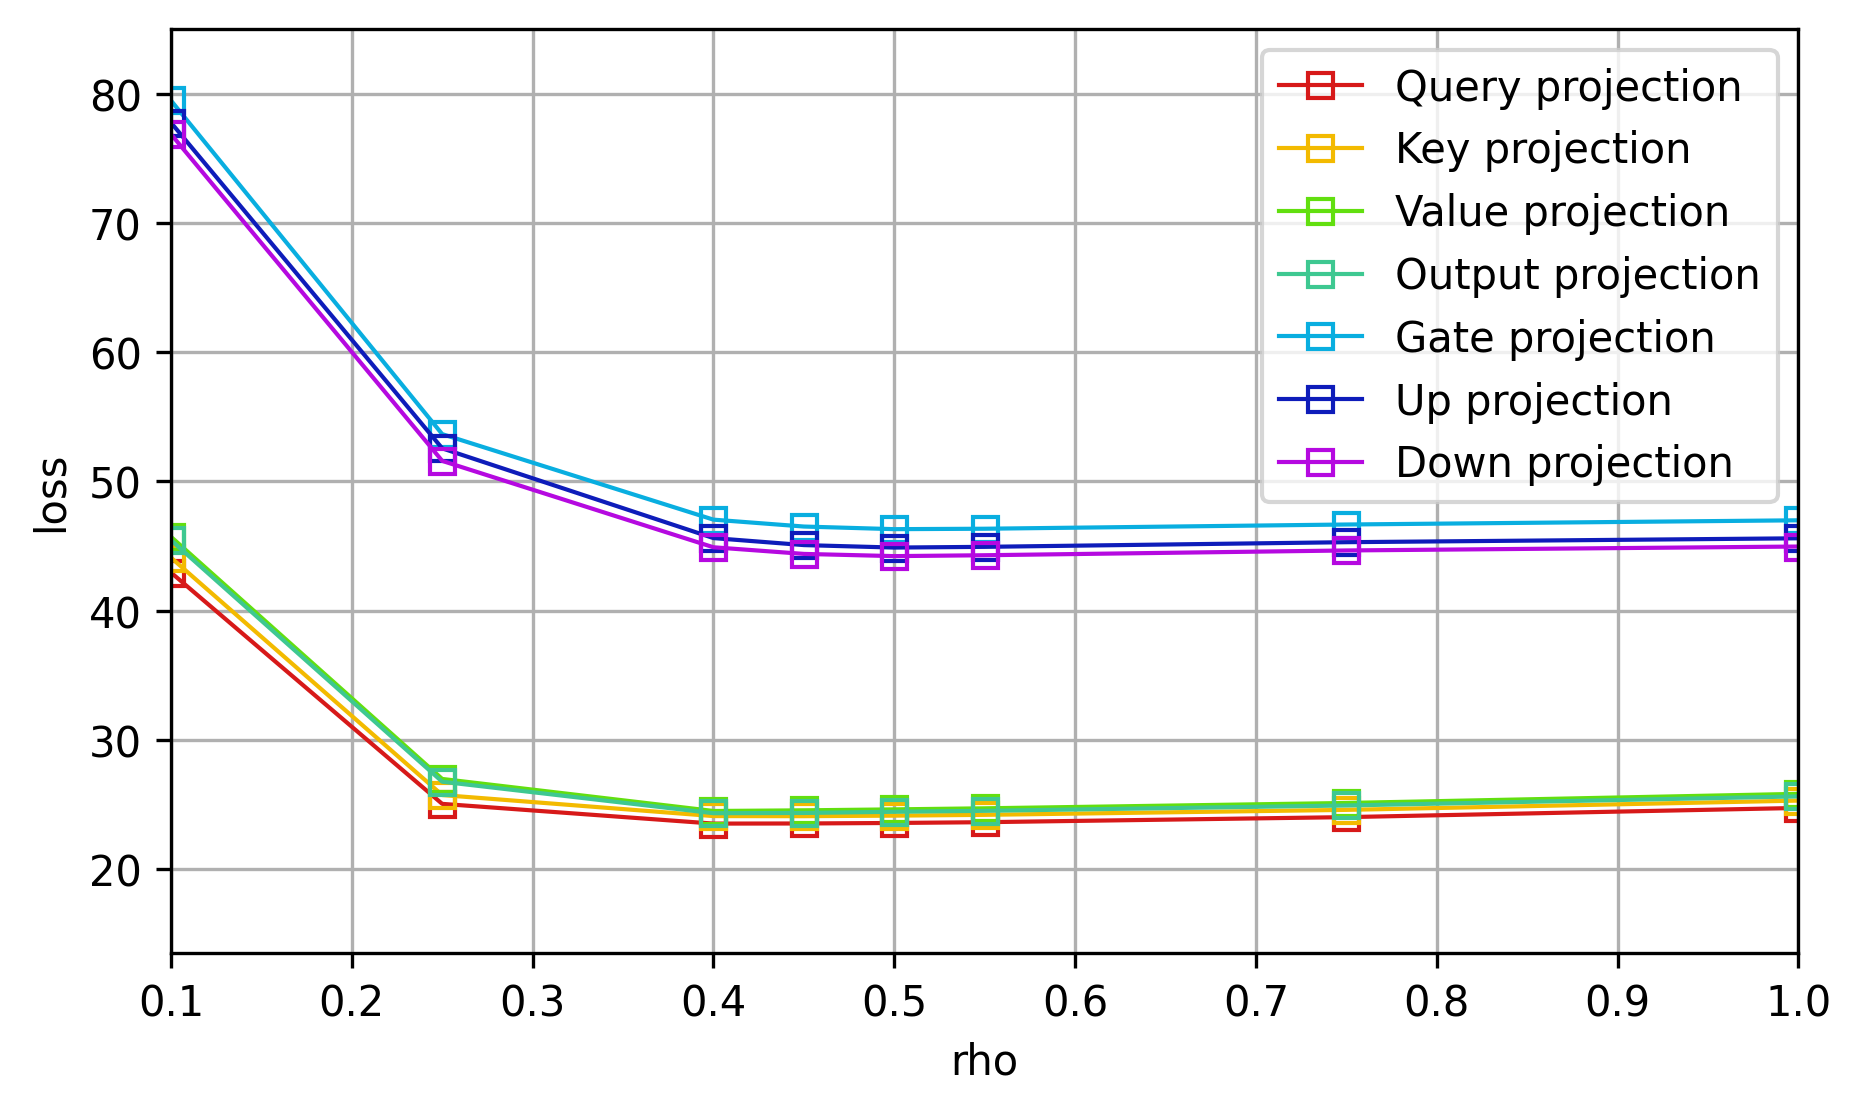

In [ ]:
# import matplotlib.pyplot as plt

# # x-axis values
# x = [0.1, 0.25, 0.4, 0.45, 0.5, 0.55, 0.75, 1]

# # y values

# q6  = [38.285, 23.518, 22.470, 22.449, 22.456, 22.487, 22.830, 23.505]
# q16 = [41.811, 24.419, 23.111, 23.101, 23.123, 23.171, 23.569, 24.299]
# q28 = [42.955, 25.053, 23.526, 23.536, 23.575, 23.635, 24.027, 24.738]

# k6  = [38.909, 24.227, 23.100, 23.072, 23.071, 23.096, 23.433, 24.108]
# k16 = [41.508, 24.571, 23.267, 23.252, 23.270, 23.315, 23.685, 24.411]
# k28 = [44.108, 25.736, 24.107, 24.100, 24.142, 24.204, 24.588, 25.306]

# v6  = [29.548, 16.758, 15.426, 15.434, 15.470, 15.522, 15.803, 16.273]
# v16 = [36.398, 20.848, 18.989, 19.025, 19.081, 19.149, 19.487, 20.068]
# v28 = [45.718, 26.981, 24.502, 24.552, 24.627, 24.709, 25.122, 25.828]

# o6  = [29.311, 16.531, 15.216, 15.226, 15.259, 15.308, 15.589, 16.046]
# o16 = [36.194, 20.817, 18.939, 18.968, 19.029, 19.097, 19.436, 20.005]
# o28 = [45.460, 26.768, 24.330, 24.350, 24.441, 24.515, 24.928, 25.631]

# mg6  = [77.419, 51.059, 45.063, 44.623, 44.517, 44.599, 44.953, 45.267]
# mg16 = [73.948, 48.745, 43.142, 42.735, 42.657, 42.731, 43.080, 43.418]
# mg28 = [79.481, 53.663, 47.046, 46.513, 46.310, 46.343, 46.670, 46.996]

# mu6  = [71.152, 47.938, 41.644, 41.160, 40.978, 41.043, 41.384, 41.653]
# mu16 = [75.192, 49.991, 43.664, 43.203, 43.060, 43.148, 43.515, 43.830]
# mu28 = [77.771, 52.563, 45.620, 45.077, 44.886, 44.942, 45.302, 45.603]

# md6  = [69.539, 45.416, 39.908, 39.543, 39.480, 39.594, 39.963, 40.264]
# md16 = [74.779, 50.247, 43.688, 43.184, 43.008, 43.074, 43.428, 43.722]
# md28 = [76.877, 51.593, 44.908, 44.395, 44.224, 44.292, 44.662, 44.966]

# # Larger figure
# plt.figure(figsize=(7, 4), dpi=300)

# # Plot with hollow square markers
# # plt.plot(x, q6, label='Query projection', color="#D71919", marker='s',
# #          markerfacecolor='none', linewidth=1)
# # plt.plot(x, q16, label='Query projection', color="#D71919", marker='s',
# #          markerfacecolor='none', linewidth=1)
# plt.plot(x, q28, label='Query projection', color="#D71919", marker='s',
#          markerfacecolor='none', linewidth=1)

# # plt.plot(x, k6, label='Key projection', color="#F3BA00", marker='s',
# #          markerfacecolor='none', linewidth=1)
# # plt.plot(x, k16, label='Key projection', color="#F3BA00", marker='s',
# #          markerfacecolor='none', linewidth=1)
# plt.plot(x, k28, label='Key projection', color="#F3BA00", marker='s',
#          markerfacecolor='none', linewidth=1)


# # plt.plot(x, v6, label='Value projection', color="#62DF0F", marker='s',
# #          markerfacecolor='none', linewidth=1)
# # plt.plot(x, v16, label='Value projection', color="#62DF0F", marker='s',
# #          markerfacecolor='none', linewidth=1)
# plt.plot(x, v28, label='Value projection', color="#62DF0F", marker='s',
#          markerfacecolor='none', linewidth=1)

# # plt.plot(x, o6, label='Output projection', color="#3EC891", marker='s',
# #          markerfacecolor='none', linewidth=1)
# # plt.plot(x, o16, label='Output projection', color="#3EC891", marker='s',
# #          markerfacecolor='none', linewidth=1)
# plt.plot(x, o28, label='Output projection', color="#3EC891", marker='s',
#          markerfacecolor='none', linewidth=1)

# # plt.plot(x, mg6, label='Gate projection', color="#09AEE0", marker='s',
# #          markerfacecolor='none', linewidth=1)
# # plt.plot(x, mg16, label='Gate projection', color="#09AEE0", marker='s',
# #          markerfacecolor='none', linewidth=1)
# plt.plot(x, mg28, label='Gate projection', color="#09AEE0", marker='s',
#          markerfacecolor='none', linewidth=1)

# # plt.plot(x, mu6, label='Up projection', color="#0E1CBA", marker='s',
# #          markerfacecolor='none', linewidth=1)
# # plt.plot(x, mu16, label='Up projection', color="#0E1CBA", marker='s',
# #          markerfacecolor='none', linewidth=1)
# plt.plot(x, mu28, label='Up projection', color="#0E1CBA", marker='s',
#          markerfacecolor='none', linewidth=1)

# # plt.plot(x, md6, label='Down projection', color="#B509E0", marker='s',
# #          markerfacecolor='none', linewidth=1)
# # plt.plot(x, md16, label='Down projection', color="#B509E0", marker='s',
# #          markerfacecolor='none', linewidth=1)
# plt.plot(x, md28, label='Down projection', color="#B509E0", marker='s',
#          markerfacecolor='none', linewidth=1)

# # Axis limits
# plt.xlim(0.2, 1)
# plt.ylim(13.5, 85)
# plt.xticks([i/10 for i in range(1, 11)])

# # Labels and legend
# plt.xlabel('rho')
# plt.ylabel('loss')
# plt.legend()

# # Grid
# plt.grid(True)
# plt.show()

In [ ]:
# q7_2x2 = test_double_sparse(q_proj_weight_7, 0.5, 0.5, 1, mask_type='blocks_alt')
# q15_2x2 = test_double_sparse(q_proj_weight_15, 0.5, 0.5, 1, mask_type='blocks_alt')
# q23_2x2 = test_double_sparse(q_proj_weight_23, 0.5, 0.5, 1, mask_type='blocks_alt')

In [ ]:
q7_1x1 = 10.132308006286621
q15_1x1 = 10.241986274719238
q23_1x1 = 10.641284942626953

q7_2x1_colrow = 17.123369216918945
q15_2x1_colrow = 17.54688835144043
q23_2x1_colrow = 18.129613876342773

# q7_2x1_rowrow = 17.125669479370117
# q15_2x1_rowrow = 17.55666732788086
# q23_2x1_rowrow = 18.12950897216797

# q7_2x1_colcol = 17.140546798706055
# q15_2x1_colcol = 17.563806533813477
# q23_2x1_colcol = 18.14604377746582

# q7_2x1_rowcol = 17.15144157409668
# q15_2x1_rowcol = 17.572513580322266
# q23_2x1_rowcol = 18.153913497924805

q7_2x2 = 23.453115463256836
q15_2x2 = 24.298742294311523
q23_2x2 = 25.018169403076172

q7_4x4 = 30.620349884033203
q15_4x4 = 32.03445816040039
q23_4x4 = 33.268218994140625

q7_8x8 = 37.110137939453125
q15_8x8 = 39.21969223022461
q23_8x8 = 40.96297073364258

q7_16x16 = 39.02204132080078
q15_16x16 = 40.88953399658203
q23_16x16 = 47.2333869934082

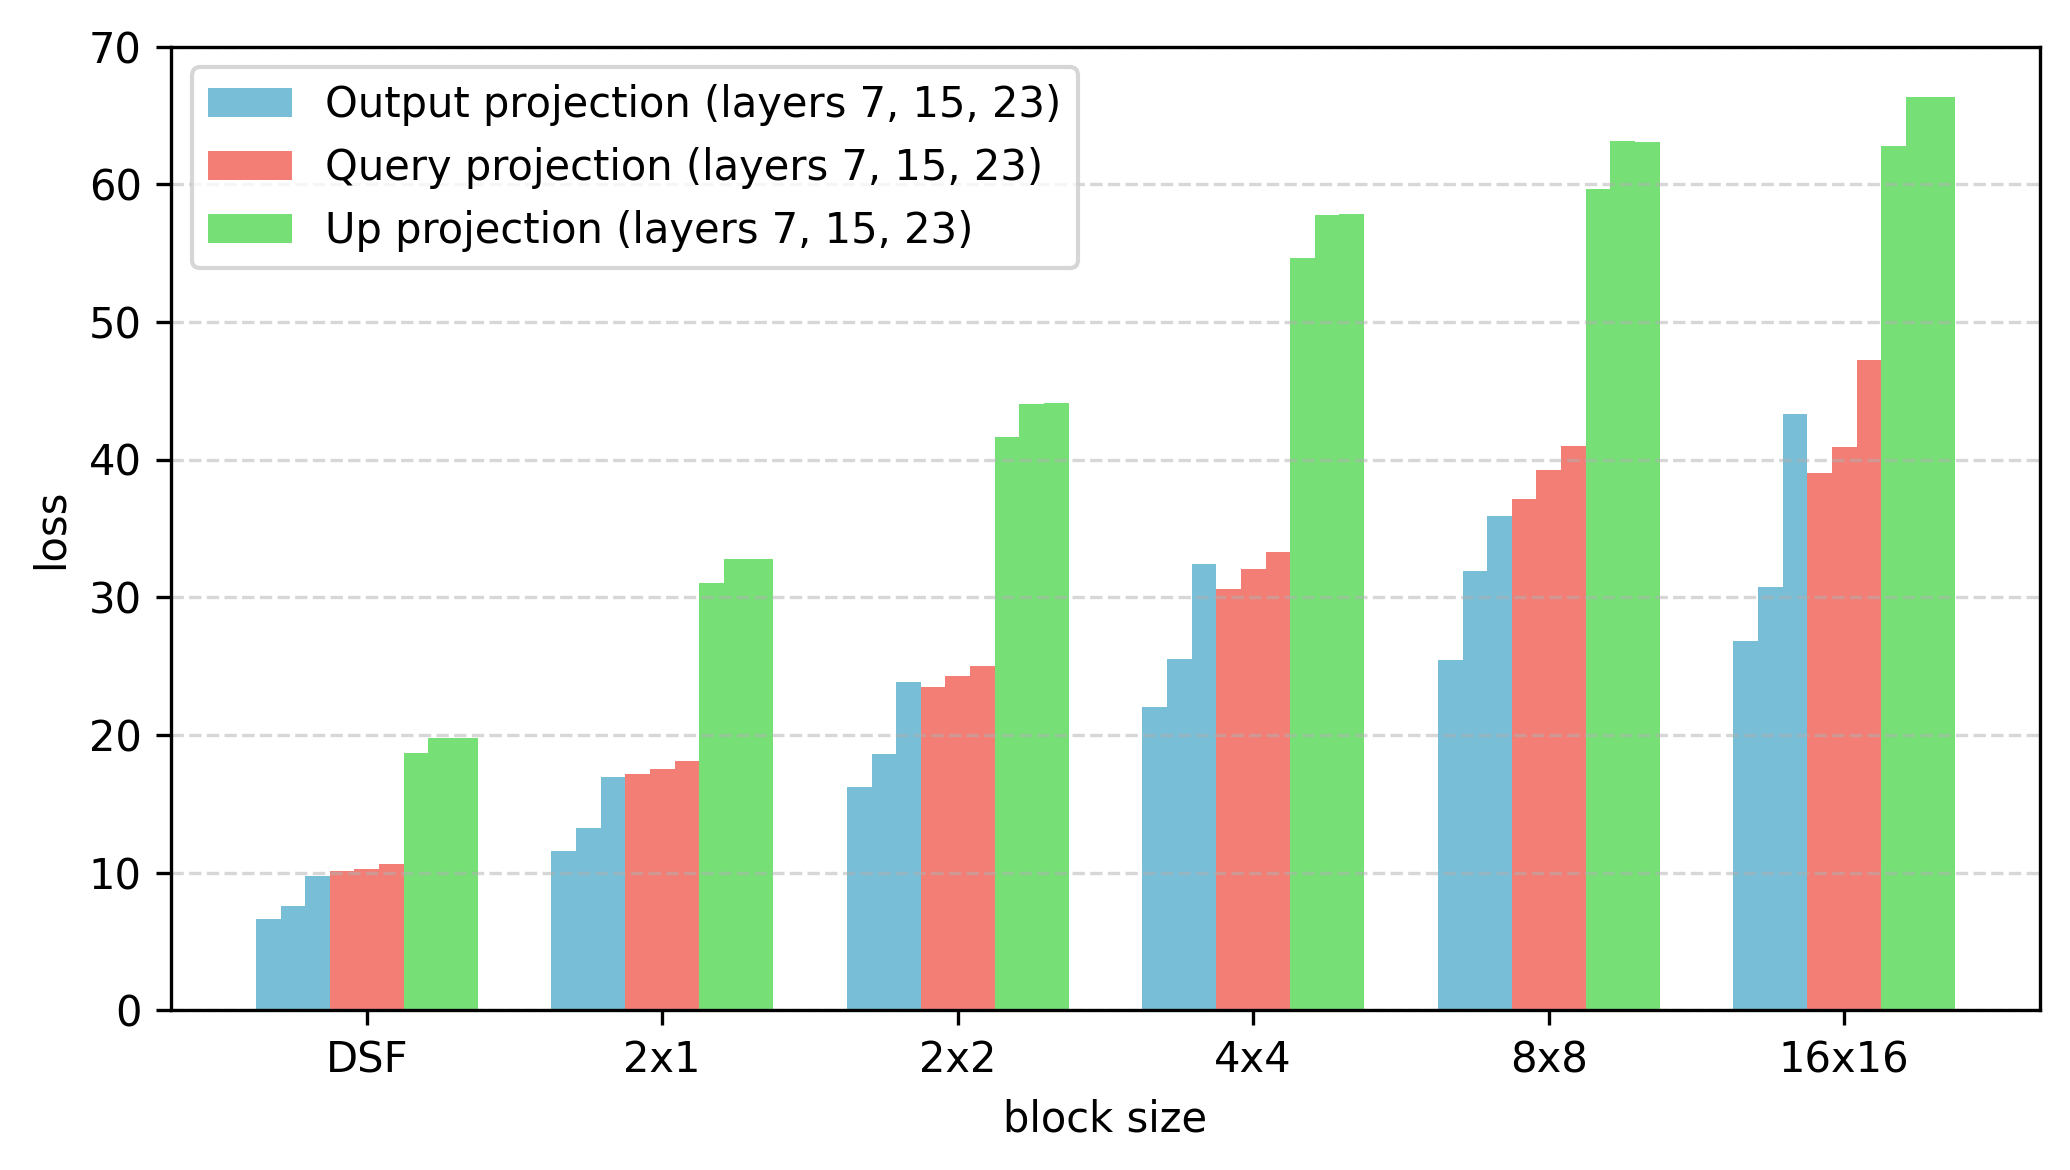

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Groups
groups = ['DSF', '2x1', '2x2', '4x4', '8x8', '16x16']
x = np.arange(len(groups))

# Values
q7  = [10.132, 17.123, 23.453, 30.620, 37.110, 39.022]
q15 = [10.242, 17.547, 24.299, 32.034, 39.220, 40.890]
q23 = [10.641, 18.130, 25.018, 33.268, 40.963, 47.233]

o7  = [6.638, 11.540, 16.218, 22.051, 25.423, 26.838]
o15 = [7.567, 13.224, 18.644, 25.493, 31.887, 30.703]
o23 = [9.720, 16.971, 23.848, 32.398, 35.864, 43.311]

mu7  = [18.695, 31.002, 41.632, 54.618, 59.616, 62.807]
mu15 = [19.799, 32.777, 44.011, 57.740, 63.170, 66.318]
mu23 = [19.783, 32.807, 44.098, 57.864, 63.072, 66.333]

outdsf = {'q7': 10.132308006286621, 'q15': 10.241986274719238, 'q23': 10.641284942626953, 'o7': 6.637629985809326, 'o15': 7.567498683929443, 'o23': 9.719768524169922, 'mu7': 18.6949462890625, 'mu15': 19.79936981201172, 'mu23': 19.7825927734375}
out2x1 = {'q7': 17.123369216918945, 'q15': 17.54688835144043, 'q23': 18.129613876342773, 'o7': 11.540096282958984, 'o15': 13.224308967590332, 'o23': 16.9708251953125, 'mu7': 31.00176429748535, 'mu15': 32.77720642089844, 'mu23': 32.806758880615234}
out2x2 = {'q7': 23.453115463256836, 'q15': 24.298742294311523, 'q23': 25.018169403076172, 'o7': 16.217567443847656, 'o15': 18.643760681152344, 'o23': 23.848196029663086, 'mu7': 41.632450103759766, 'mu15': 44.01103210449219, 'mu23': 44.097938537597656}
out4x4 = {'q7': 30.620349884033203, 'q15': 32.03445816040039, 'q23': 33.268218994140625, 'o7': 22.051237106323242, 'o15': 25.493396759033203, 'o23': 32.39784622192383, 'mu7': 54.618045806884766, 'mu15': 57.7403450012207, 'mu23': 57.864463806152344}
out8x8 = {'q7': 37.110137939453125, 'q15': 39.21969223022461, 'q23': 40.96297073364258, 'o7': 25.423376083374023, 'o15': 31.88718032836914, 'o23': 35.8644905090332, 'mu7': 59.616355895996094, 'mu15': 63.16985321044922, 'mu23': 63.07236099243164}
out16x16 = {'q7': 39.02204132080078, 'q15': 40.88953399658203, 'q23': 47.2333869934082, 'o7': 26.838003158569336, 'o15': 30.70256233215332, 'o23': 43.31079864501953, 'mu7': 62.80747604370117, 'mu15': 66.3176498413086, 'mu23': 66.33306884765625}

# Bar width
width = 0.25/3

# Figure (high DPI)
plt.figure(figsize=(7, 4), dpi=300)

# Pastel colors (same across groups)
color_q7  = "#79BED7"  # pastel blue
color_q15 = "#F37E76"  # pastel red
color_q23 = "#76E076"  # pastel green

# Plot grouped bars
plt.bar(x - 4*width, o7,  width, color=color_q7)
plt.bar(x - 3*width, o15,  width, label='Output projection (layers 7, 15, 23)',  color=color_q7)
plt.bar(x - 2*width, o23,  width, color=color_q7)
plt.bar(x - 1*width, q7, width, color=color_q15)
plt.bar(x          , q15, width, label='Query projection (layers 7, 15, 23)', color=color_q15)
plt.bar(x + 1*width, q23, width, color=color_q15)
plt.bar(x + 2*width, mu7, width, color=color_q23)
plt.bar(x + 3*width, mu15, width, label='Up projection (layers 7, 15, 23)', color=color_q23)
plt.bar(x + 4*width, mu23, width, color=color_q23)

# Axes formatting
plt.xticks(x, groups)
plt.ylim(0, 70)
plt.yticks(np.arange(0, 71, 10))

# Labels & legend
plt.xlabel('block size')
plt.ylabel('loss')
plt.legend(loc='upper left')

# Grid (optional but helps readability)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# q7_2x2 = test_double_sparse(q_proj_weight_7, 0.5, 0.5, 1, mask_type='blocks')
# q15_2x2 = test_double_sparse(mlp_down_weight_15, 0.5, 0.5, 1, mask_type='blocks')

In [ ]:
q7_2x2_125p_375p = 23.643545150756836
q15_2x2_125p_375p = 24.829833984375
q23_2x2_125p_375p = 25.581159591674805

q7_2x2_20p_30p = 23.164443969726562
q15_2x2_20p_30p = 24.083036422729492
q23_2x2_20p_30p = 24.837310791015625

q7_2x2_25p_25p = 23.453115463256836
q15_2x2_25p_25p = 24.298742294311523
q23_2x2_25p_25p = 25.018169403076172

q7_2x2_375p_125p = 26.42716407775879
q15_2x2_375p_125p = 27.068979263305664
q23_2x2_375p_125p = 27.9689884185791


o7_2x2_125p_375p = 17.115551
o15_2x2_125p_375p = 19.705472946166992
o23_2x2_125p_375p = 25.003847122192383

o7_2x2_20p_30p = 16.28129005432129
o15_2x2_20p_30p = 18.71734046936035
o23_2x2_20p_30p = 23.90760612487793

o7_2x2_25p_25p = 16.217567443847656
o15_2x2_25p_25p = 18.643760681152344
o23_2x2_25p_25p = 23.848196029663086

o7_2x2_375p_125p = 17.73960304260254
o15_2x2_375p_125p = 20.45415496826172
o23_2x2_375p_125p = 26.226451873779297


mlpup7_2x2_407p_25p = 41.632450103759766
mlpup15_2x2_407p_25p = 44.01103210449219
mlpup23_2x2_407p_25p = 44.097938537597656

mlpup7_2x2_360p_375p = 40.40531539916992
mlpup15_2x2_360p_375p = 42.69010543823242
mlpup23_2x2_360p_375p = 42.748512268066406

mlpup7_2x2_314p_50p = 40.26658248901367
mlpup15_2x2_314p_50p = 42.532840728759766
mlpup23_2x2_314p_50p = 42.59101486206055


mlpdown7_2x2_407p_25p = 40.1270751953125
mlpdown15_2x2_407p_25p = 43.27824401855469
mlpdown23_2x2_407p_25p = 44.18965148925781

mlpdown7_2x2_360p_375p = 38.80428695678711
mlpdown15_2x2_360p_375p = 41.95237731933594
mlpdown23_2x2_360p_375p = 42.881065368652344

mlpdown7_2x2_314p_50p = 38.57448196411133
mlpdown15_2x2_314p_50p = 41.790103912353516
mlpdown23_2x2_314p_50p = 42.743751525878906

In [ ]:
# start = time()
# q15_2x2 = test_double_sparse(q_proj_weight_15, 0.5, 0.5, 1, mask_type='blocks_alt')
# end = time() - start
# print(end)

In [ ]:
# start = time()
# mlpup_2x2 = test_double_sparse(mlp_up_weight_15, 0.5, 0.5, 1, mask_type='blocks_alt')
# end = time() - start
# print(end)

In [ ]:
q15_dsf_secs = 17.998
mlpup_dsf_secs = 32.483

q15_2x2_secs = 20.397
q15_2x2_secs_middim2 = 61.065
mlpup_2x2_secs = 38.630

q15_2x1_secs = 25.257
q15_2x1_secs_middim2 = 68.914
mlpup_2x1_secs = 46.979

q15_2to4_secs = 25.037
q15_2to4_secs_middim2 = 74.769
mlpup_2to4_secs = 47.045

qwen3_k15_secs = 3.4195



q15_2to4_norm = 14.211647987365723
q15_2to4_secs = 24.622774600982666

q15_2to4_cp_norm = 14.22008991241455
q15_2to4_cp_secs = 25.32834

q15_2to4_cp12_norm = 14.218571662902832
q15_2to4_cp12_secs = 25.25075674057007


mlpup15_2to4_norm = 27.17522430419922
mlpup15_2to4_secs = 46.42337131500244

mlpup15_2to4_cp_norm = 27.17560
mlpup15_2to4_cp_secs = 47.34501099586487

mlpup15_2to4_cp12_norm = 27.17211151123047
mlpup15_2to4_cp12_secs = 47.462169885635376


q15_2x1_norm = 17.54688835144043
q15_2x1_secs = 25.020596265792847

q15_2x1_cp_norm = 17.53778648376465
q15_2x1_cp_secs = 25.488643646240234

q15_2x1_cp12_norm = 17.54064178466797
q15_2x1_cp12_secs = 25.448254585266113

mlpup15_2x1_norm = 32.630680084228516
mlpup15_2x1_secs = 46.44873905181885

mlpup15_2x1_cp_norm = 32.62998962402344
mlpup15_2x1_cp_secs = 47.38391351699829

mlpup15_2x1_cp12_norm = 32.63258743286133
mlpup15_2x1_cp12_secs = 47.5490882396698

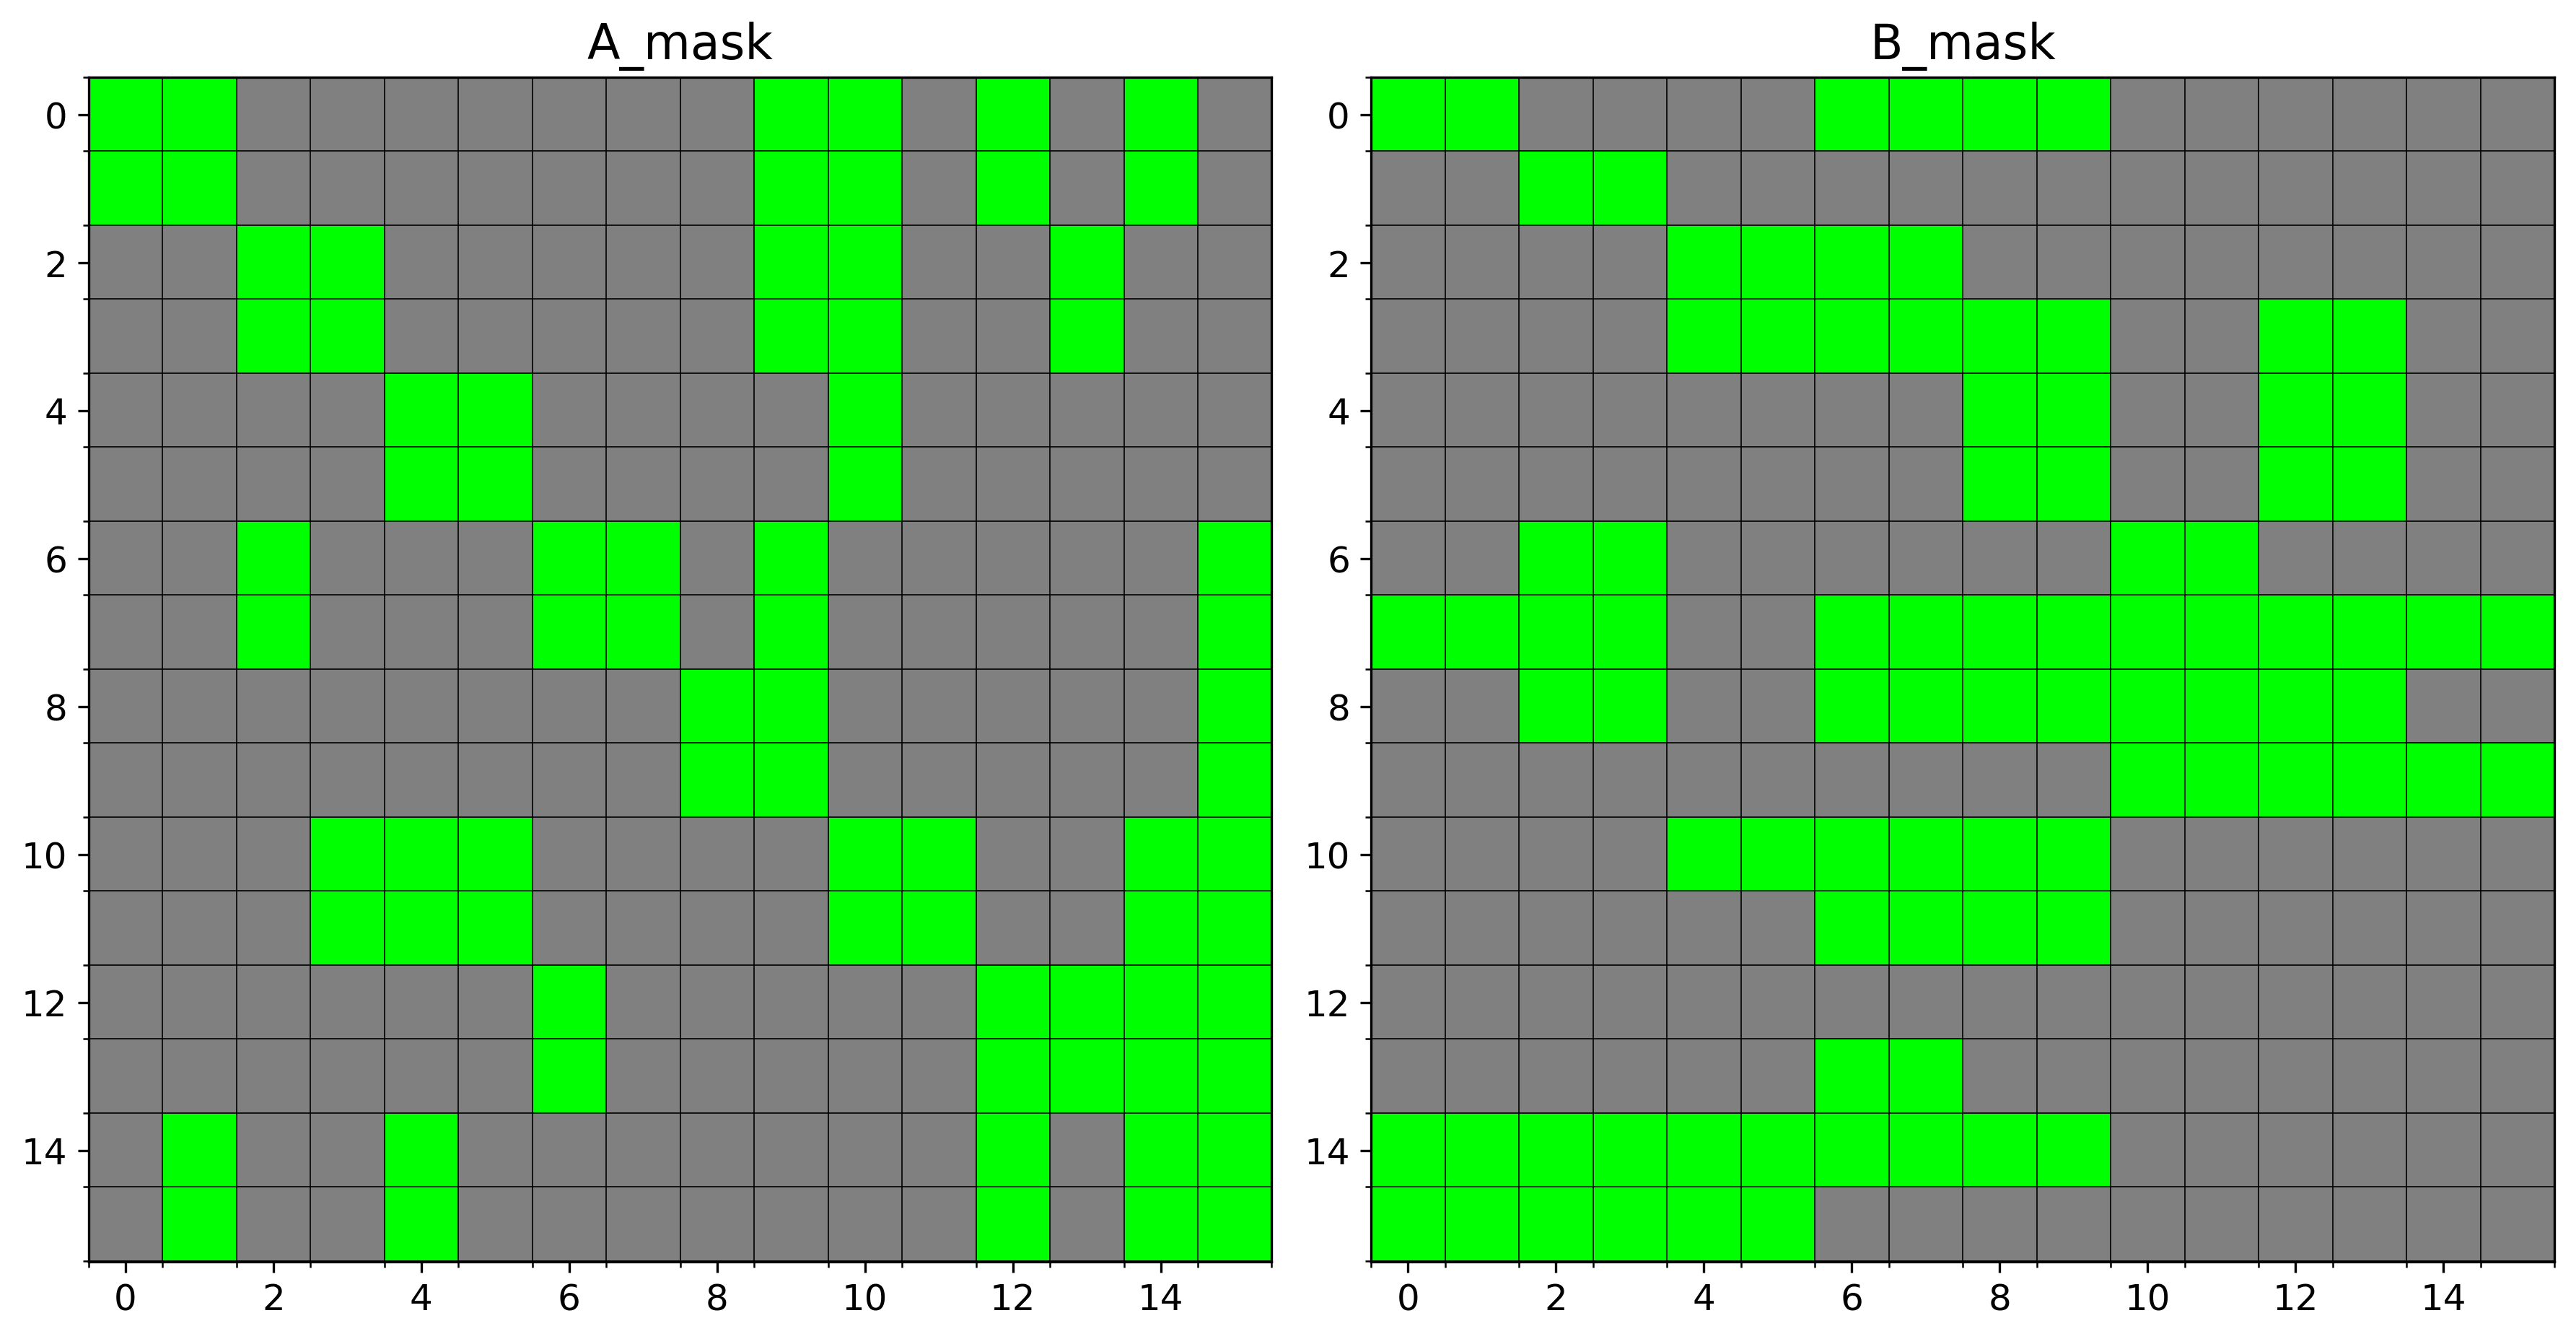

Frobenius pre-finalization:  15.755908966064453
Frobenius norm: 15.755908966064453
A: tensor([[ 0.8063,  0.0487, -0.0000,  0.0000],
        [ 0.0068,  0.8552, -0.0000, -0.0000],
        [ 0.0000, -0.0000,  0.8070,  0.0129],
        [ 0.0000,  0.0000, -0.0426,  0.7959]])
B: tensor([[ 0.0017,  0.0297,  0.0000, -0.0000],
        [-0.0000, -0.0000, -0.0238, -0.0038],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000, -0.0000, -0.0000]])
A.size() = torch.Size([4096, 4096])
B.size() = torch.Size([4096, 4096])
AB: tensor([[ 0.0009,  0.0319, -0.0065,  ..., -0.0085, -0.0092, -0.0111],
        [-0.0016, -0.0147, -0.0198,  ...,  0.0014, -0.0133,  0.0020],
        [ 0.0105, -0.0198, -0.0193,  ...,  0.0116, -0.0426, -0.0315],
        ...,
        [ 0.0131,  0.0156,  0.0042,  ..., -0.0002,  0.0277,  0.0117],
        [ 0.0181,  0.0230,  0.0005,  ..., -0.0060, -0.0034, -0.0169],
        [-0.0192, -0.0159, -0.0571,  ...,  0.0084,  0.0016, -0.0313]])
Input matrix was: tensor([[ 0.0

In [ ]:
from time import time
from test_dbsf import *

start = time()
q15_2x2 = test_double_sparse(v_proj_weight_23, 0.5, 0.5, 1, mask_type='blocks_alt')
end = time() - start
print(end)

In [ ]:
mlpdown7_2x2_no_tetris = 38.5744819641113
mlpdown7_2x2_no_tetris_seconds = 38.51993656158447

mlpdown7_2x2_tetris = 38.60469055175781
mlpdown7_2x2_tetris_seconds = 91.65945792198181

mlpdown7_2x2_tetris_it3 = 38.58454132080078
mlpdown7_2x2_tetris_it3_seconds = 91.54047346115112

mlpdown7_2x2_tetris_it1 = 38.61601257324219
mlpdown7_2x2_tetris_it1_seconds = 91.21226334571838

mlpdown7_2x1_no_tetris = 29.536575317382812
mlpdown7_2x1_no_tetris_seconds = 47.718810081481934

mlpdown7_2x1_tetris = 29.06410789489746
mlpdown7_2x1_tetris_seconds = 101.11837577819824

mlpdown7_2to4_no_tetris = 24.607154846191406
mlpdown7_2to4_no_tetris_seconds = 46.1153826713562

mlpdown7_2to4_tetris = 24.1757755279541
mlpdown7_2to4_tetris_seconds = 100.62246894836426


q15_2x2_no_tetris_norm = 24.29874
q15_2x2_no_tetris_seconds = 20.80595636367798

q15_2x2_tetris_norm = 24.0827579498291
q15_2x2_tetris_seconds = 49.422743797302246

q15_2x1_no_tetris_norm = 17.54064178466797
q15_2x1_no_tetris_seconds = 25.550762176513672

q15_2x1_tetris_norm = 17.169456481933594
q15_2x1_tetris_seconds = 55.11411213874817

q15_2to4_no_tetris_norm = 14.211647987365723
q15_2to4_no_tetris_seconds = 24.84253716468811

q15_2to4_tetris_norm = 14.029687881469727
q15_2to4_tetris_seconds = 54.16424369812012



mlpdown15_2x2_no_tetris_norm = 41.790103912353516
mlpdown15_2x2_no_tetris_seconds = 39.063907623291016

mlpdown15_2x2_tetris_norm = 41.841922760009766
mlpdown15_2x2_tetris_seconds = 91.90242910385132

mlpdown15_2x1_no_tetris_norm = 32.0628547668457
mlpdown15_2x1_no_tetris_seconds = 47.86954092979431

mlpdown15_2x1_tetris_norm = 31.56764030456543
mlpdown15_2x1_tetris_seconds = 101.29106450080872

mlpdown15_2to4_no_tetris_norm = 26.711050033569336
mlpdown15_2to4_no_tetris_seconds = 46.58864617347717

mlpdown15_2to4_tetris_norm = 26.25615692138672
mlpdown15_2to4_tetris_seconds = 101.03820538520813


v23_2x2_no_tetris_norm = 0
v23_2x2_no_tetris_seconds = 0

v23_2x2_tetris_norm = 0
v23_2x2_tetris_seconds = 0

v23_2x1_no_tetris_norm = 16.899744033813477
v23_2x1_no_tetris_seconds = 25.610812425613403

v23_2x1_tetris_norm = 16.485729217529297
v23_2x1_tetris_seconds = 54.967862606048584

v23_2to4_no_tetris_norm = 13.367036819458008
v23_2to4_no_tetris_seconds = 24.876603603363037

v23_2to4_tetris_norm = 13.006450653076172
v23_2to4_tetris_seconds = 53.673781394958496